In [33]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv


In [34]:
retail = pd.read_csv('/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv')

print(f" Данные загружены: {retail.shape[0]:,} строк")
print(f" Столбцы: {retail.columns.tolist()}")
print(f"\nПервые 3 строки:")
print(retail.head(5))

 Данные загружены: 1,067,371 строк
 Столбцы: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Первые 3 строки:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [35]:

print("\n ПРОВЕРКА ДАННЫХ:")
print(f"Дубликатов: {retail.duplicated().sum()}")
print(f"Пропусков:\n{retail.isna().sum()}")

# Конвертируем дату
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])

print(f"\n Дата конвертирована")
print(f"Период: {retail['InvoiceDate'].min().date()} до {retail['InvoiceDate'].max().date()}")


 ПРОВЕРКА ДАННЫХ:
Дубликатов: 34335
Пропусков:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

 Дата конвертирована
Период: 2009-12-01 до 2011-12-09


In [36]:
print("\n ОЧИСТКА ДАННЫХ:")

# Начальное кол-во
initial_rows = len(retail)

# Убираем ошибки
retail = retail[retail['Quantity'] > 0]
retail = retail[retail['Price'] > 0]
retail = retail[retail['Customer ID'].notna()]

# Считаем выручку
retail['Revenue'] = retail['Quantity'] * retail['Price']

removed = initial_rows - len(retail)
print(f"Удалено строк: {removed:,} ({removed/initial_rows*100:.1f}%)")
print(f"Осталось: {len(retail):,} строк")
print(f"Уникальные клиенты: {retail['Customer ID'].nunique():,}")
print(f"Уникальные товары: {retail['StockCode'].nunique():,}")


 ОЧИСТКА ДАННЫХ:
Удалено строк: 261,822 (24.5%)
Осталось: 805,549 строк
Уникальные клиенты: 5,878
Уникальные товары: 4,631


In [37]:
print("\n СОЗДАНИЕ КОГОРТ:")

# Находим первую покупку каждого клиента
first_purchase = retail.groupby('Customer ID')['InvoiceDate'].min().reset_index()
first_purchase.columns = ['Customer ID', 'cohort_date']

# Конвертируем в период (месяц)
first_purchase['cohort_month'] = first_purchase['cohort_date'].dt.to_period('M')

print(f" Когорты найдены для {len(first_purchase):,} клиентов")
print(f"Период когорт: {first_purchase['cohort_month'].min()} до {first_purchase['cohort_month'].max()}")


 СОЗДАНИЕ КОГОРТ:
 Когорты найдены для 5,878 клиентов
Период когорт: 2009-12 до 2011-12


In [38]:

print("\n РАСЧЁТ COHORT INDEX:")

# Добавляем информацию о когорте к основной таблице
retail_cohort = retail.merge(first_purchase, on='Customer ID')

# Считаем месяц каждого заказа
retail_cohort['order_month'] = retail_cohort['InvoiceDate'].dt.to_period('M')

# Считаем cohort_index (M+0, M+1, M+2, ...)
retail_cohort['cohort_index'] = (
    retail_cohort['order_month'] - retail_cohort['cohort_month']
).apply(lambda x: x.n)

print(f" Cohort Index рассчитан")
print(f"Диапазон: M+{retail_cohort['cohort_index'].min()} до M+{retail_cohort['cohort_index'].max()}")

# Примеры
print(f"\nПримеры когорт:")
print(retail_cohort[['Customer ID', 'cohort_month', 'order_month', 'cohort_index']].head(10))


 РАСЧЁТ COHORT INDEX:
 Cohort Index рассчитан
Диапазон: M+0 до M+24

Примеры когорт:
   Customer ID cohort_month order_month  cohort_index
0      13085.0      2009-12     2009-12             0
1      13085.0      2009-12     2009-12             0
2      13085.0      2009-12     2009-12             0
3      13085.0      2009-12     2009-12             0
4      13085.0      2009-12     2009-12             0
5      13085.0      2009-12     2009-12             0
6      13085.0      2009-12     2009-12             0
7      13085.0      2009-12     2009-12             0
8      13085.0      2009-12     2009-12             0
9      13085.0      2009-12     2009-12             0


In [39]:
print("\n СОЗДАНИЕ RETENTION MATRIX:")

# Считаем уникальных клиентов в каждой когорте и каждом месяце
cohort_data = retail_cohort.groupby(['cohort_month', 'cohort_index'])['Customer ID'].nunique().reset_index()

# Pivot таблица
cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='Customer ID'
)

print(f" Cohort Pivot создана: {cohort_pivot.shape}")
print(f"\nПервые 5 когорт:")
print(cohort_pivot.iloc[:5, :8])

# Нормализуем (считаем процент от размера когорты)
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100  # в процентах

print(f"\n Retention Matrix рассчитана (в процентах)")
print(f"\nПримеры retention rates:")
print(retention_matrix.iloc[:5, :8].round(1))


 СОЗДАНИЕ RETENTION MATRIX:
 Cohort Pivot создана: (25, 25)

Первые 5 когорт:
cohort_index      0      1      2      3      4      5      6      7
cohort_month                                                        
2009-12       955.0  337.0  319.0  406.0  363.0  343.0  360.0  327.0
2010-01       383.0   79.0  119.0  117.0  101.0  115.0   99.0   88.0
2010-02       374.0   89.0   84.0  109.0   92.0   75.0   72.0  107.0
2010-03       443.0   84.0  102.0  107.0  103.0   90.0  109.0  134.0
2010-04       294.0   57.0   57.0   48.0   54.0   66.0   81.0   77.0

 Retention Matrix рассчитана (в процентах)

Примеры retention rates:
cohort_index      0     1     2     3     4     5     6     7
cohort_month                                                 
2009-12       100.0  35.3  33.4  42.5  38.0  35.9  37.7  34.2
2010-01       100.0  20.6  31.1  30.5  26.4  30.0  25.8  23.0
2010-02       100.0  23.8  22.5  29.1  24.6  20.1  19.3  28.6
2010-03       100.0  19.0  23.0  24.2  23.3  20.3  24.6  3

Фильтровано: 12 когорт, M+0 до M+12


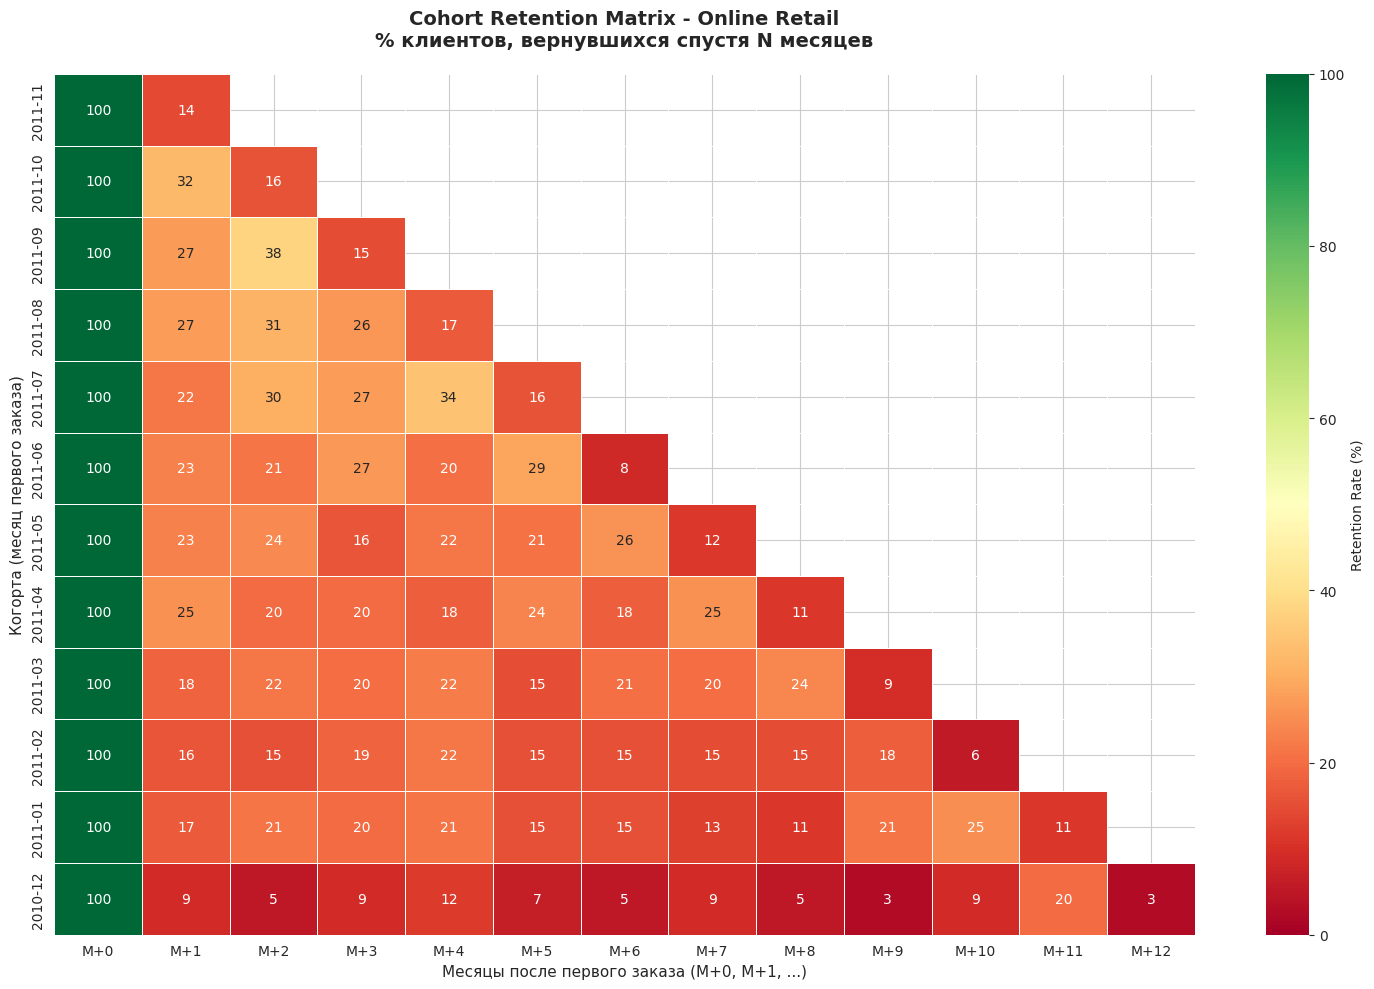

In [40]:


# Берём только первые 12 месяцев (M+0 до M+11) и когорты с достаточным размером
retention_filtered = retention_matrix[retention_matrix.index >= '2010-12'].copy()
retention_filtered = retention_filtered.iloc[:, :13]  # M+0 до M+12
cohort_size_filtered = cohort_size.loc[retention_filtered.index]
retention_filtered = retention_filtered[cohort_size_filtered >= 50]

print(f"Фильтровано: {retention_filtered.shape[0]} когорт, M+0 до M+{retention_filtered.shape[1]-1}")

# График
fig, ax = plt.subplots(figsize=(15, 10))

sns.heatmap(
    retention_filtered.iloc[::-1],  # Обратный порядок (новые сверху)
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)'}
)

ax.set_title(
    'Cohort Retention Matrix - Online Retail\n% клиентов, вернувшихся спустя N месяцев',
    fontsize=14, fontweight='bold', pad=20
)
ax.set_xlabel('Месяцы после первого заказа (M+0, M+1, ...)', fontsize=11)
ax.set_ylabel('Когорта (месяц первого заказа)', fontsize=11)

# Форматируем метки
ax.set_xticklabels([f'M+{i}' for i in range(retention_filtered.shape[1])], rotation=0)

plt.tight_layout()
plt.show()



 АНАЛИЗ RETENTION CURVE

 СРЕДНЯЯ КРИВАЯ RETENTION:
   M+ 0: 100.0%
   M+ 1:  21.2%
   M+ 3:  21.6%
   M+ 6:  17.8%
   M+12:  18.2%


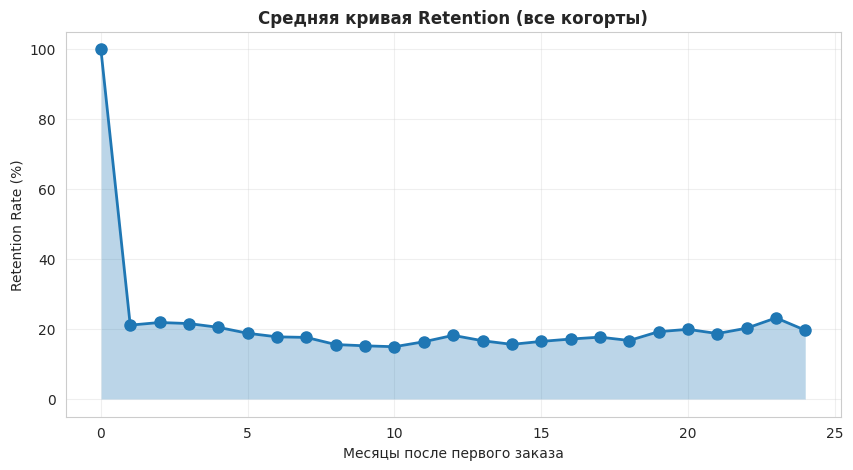

In [41]:
print(" АНАЛИЗ RETENTION CURVE")

# Средняя кривая retention по всем когортам
avg_retention = retention_matrix.mean()

print(f"\n СРЕДНЯЯ КРИВАЯ RETENTION:")
for month in [0, 1, 3, 6, 12]:
    if month in avg_retention.index:
        print(f"   M+{month:2d}: {avg_retention[month]:5.1f}%")

# График средней кривой
plt.figure(figsize=(10, 5))
avg_retention.plot(marker='o', linewidth=2, markersize=8)
plt.fill_between(range(len(avg_retention)), avg_retention.values, alpha=0.3)
plt.title('Средняя кривая Retention (все когорты)', fontsize=12, fontweight='bold')
plt.xlabel('Месяцы после первого заказа')
plt.ylabel('Retention Rate (%)')
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
print(" КЛЮЧЕВЫЕ ВЫВОДЫ")

# Считаем падение retention
retention_m0 = avg_retention[0]
retention_m1 = avg_retention[1] if 1 in avg_retention.index else None
retention_m3 = avg_retention[3] if 3 in avg_retention.index else None

if retention_m1:
    drop_m1 = retention_m0 - retention_m1
    print(f"\n ПАДЕНИЕ RETENTION:")
    print(f"   M+0 → M+1: {drop_m1:.1f}% потеря (падение на {drop_m1/retention_m0*100:.0f}%)")

if retention_m3:
    drop_m3 = retention_m0 - retention_m3
    print(f"   M+0 → M+3: {drop_m3:.1f}% потеря (падение на {drop_m3/retention_m0*100:.0f}%)")

print(f"\n КРИТИЧЕСКИЙ ПЕРИОД:")
print(f"    Первый месяц: максимальное выбывание")
print(f"    Месяцы 1-3: продолжается отток")
print(f"    После месяца 3: стабилизация")

print(f"\n КАЧЕСТВО КОГОРТ:")
old_cohorts_retention = retention_matrix.iloc[:5].mean()
new_cohorts_retention = retention_matrix.iloc[-5:].mean()
print(f"    Старые когорты (М+0): {old_cohorts_retention[0]:.0f}% средний M+1")
print(f"    Новые когорты (М+0): {new_cohorts_retention[0]:.0f}% средний M+1")
print(f"    Тренд: {'улучшаются ' if new_cohorts_retention[0] > old_cohorts_retention[0] else 'ухудшаются '}")



 КЛЮЧЕВЫЕ ВЫВОДЫ

 ПАДЕНИЕ RETENTION:
   M+0 → M+1: 78.8% потеря (падение на 79%)
   M+0 → M+3: 78.4% потеря (падение на 78%)

 КРИТИЧЕСКИЙ ПЕРИОД:
    Первый месяц: максимальное выбывание
    Месяцы 1-3: продолжается отток
    После месяца 3: стабилизация

 КАЧЕСТВО КОГОРТ:
    Старые когорты (М+0): 100% средний M+1
    Новые когорты (М+0): 100% средний M+1
    Тренд: ухудшаются 
